# DAMICORE abuse categories

## Research proposal

**Question:** do violence-related source categories reported for female victims show recurring contextual profiles?

**Unit of analysis:** one source category, not one person or one report. Every female-victim report from January through June 2026 contributes to the aggregate profile of each eligible category in which it appears.

**Operational scope:** categories under `INTEGRIDADE`, `VIDA`, or `VIOLÊNCIA INSTITUCIONAL`, plus `LIBERDADE > SEXUAL` and the source category for gender-based political violence. This source-taxonomy rule is exploratory, not a legal definition of violence against women.

**Representation:** every category receives the same ordered context vocabulary. Each value is serialized as fixed-width prevalence per 10,000 reports, including zeroes. Total category support is kept outside the compressed document.

**Exploratory hypothesis:** categories with similar normalized age, relationship, setting, and monthly profiles will have lower NCD distances, appear near each other in the DAMICORE tree, and tend to share a cluster.

The experiment follows one chain: `normalized contextual prevalence → NCD distance matrix → bias diagnostic → tree → DAMICORE clusters → NetworkX views`. It proposes a data-derived comparison of contextual profiles; it does not propose confirmed legal typologies.


In [9]:
from pathlib import Path
from io import StringIO
from itertools import combinations
from math import log10
import os

import matplotlib.pyplot as plt
from matplotlib.colors import to_hex
from matplotlib.patches import Patch
import networkx as nx
import pandas as pd
import psycopg
from Bio import Phylo
from damicore import estimate, run
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise RuntimeError("Run this notebook from the repository root or notebooks directory.")

DATABASE_URL = os.getenv("DISQUE100_DATABASE_URL", "postgresql:///disque100")
START_DATE = "2026-01-01"
END_DATE = "2026-07-01"
VICTIM_GENDER = "FEMININO"
MIN_REPORT_COUNT = 50
BIAS_WARNING_THRESHOLD = 0.70

ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "damicore_abuse_categories_2026_h1"
WORK_DIR = ARTIFACT_DIR / "work"
CORPUS_DIR = WORK_DIR / "normalized-corpus"
RUN_DIR = WORK_DIR / "normalized-run"
RESULTS_DIR = ARTIFACT_DIR / "results"
CORPUS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


## 1. Coverage, scope, and aggregate contexts

`source_hash` is used only inside PostgreSQL to count distinct reports. The notebook receives coverage totals and aggregate counts, never individual reports. Missing age, relationship, and setting values become `UNKNOWN` so every report remains represented.


In [10]:
category_sql = '''
nullif(concat_ws(' > ',
    nullif(trim(split_part(violation, '>', 1)), ''),
    nullif(trim(split_part(violation, '>', 2)), '')
), '')
'''

coverage_query = f'''
WITH reports AS (
    SELECT source_hash,
           bool_or(violation IS NOT NULL) AS has_violation,
           bool_or(({category_sql}) IS NOT NULL) AS has_category
    FROM public.disque100_reports
    WHERE registered_at >= %s AND registered_at < %s
      AND victim_gender = %s
    GROUP BY source_hash
)
SELECT count(*) AS female_reports,
       count(*) FILTER (WHERE has_category) AS reports_with_category,
       count(*) FILTER (WHERE NOT has_violation) AS reports_without_violation
FROM reports
'''

context_query = f'''
WITH report_values AS (
    SELECT DISTINCT
        source_hash,
        {category_sql} AS category,
        coalesce(victim_age_group, 'UNKNOWN') AS age_group,
        coalesce(victim_suspect_relationship, 'UNKNOWN') AS relationship,
        coalesce(violation_setting, 'UNKNOWN') AS setting,
        to_char(date_trunc('month', registered_at), 'YYYY-MM') AS month
    FROM public.disque100_reports
    WHERE registered_at >= %s AND registered_at < %s
      AND victim_gender = %s
), contexts AS (
    SELECT category, source_hash, 'report'::text AS dimension, 'ALL'::text AS value
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'age_group', age_group
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'relationship', relationship
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'setting', setting
    FROM report_values WHERE category IS NOT NULL
    UNION ALL
    SELECT category, source_hash, 'month', month
    FROM report_values WHERE category IS NOT NULL
)
SELECT category, dimension, value, count(DISTINCT source_hash) AS report_count
FROM contexts
GROUP BY category, dimension, value
ORDER BY category, dimension, value
'''

parameters = (START_DATE, END_DATE, VICTIM_GENDER)
with psycopg.connect(DATABASE_URL) as connection:
    with connection.cursor() as cursor:
        cursor.execute(coverage_query, parameters)
        coverage = pd.DataFrame(cursor.fetchall(), columns=[column.name for column in cursor.description])
        cursor.execute(context_query, parameters)
        context_counts = pd.DataFrame(cursor.fetchall(), columns=[column.name for column in cursor.description])

display(coverage.rename(columns={
    "female_reports": "Female-victim reports",
    "reports_with_category": "Reports with category",
    "reports_without_violation": "Reports without violation",
}))
category_support = (
    context_counts.loc[context_counts["dimension"] == "report", ["category", "report_count"]]
    .rename(columns={"report_count": "category_report_count"})
    .sort_values("category")
)

scope_mask = (
    category_support["category"].str.startswith(("INTEGRIDADE", "VIDA", "VIOLÊNCIA INSTITUCIONAL"))
    | category_support["category"].eq("LIBERDADE > SEXUAL")
    | category_support["category"].str.contains(
        "VIOLÊNCIA POLITÍCA DE GÊNERO E CONTRA AS MULHERES", regex=False
    )
)
category_support["status"] = "included"
category_support.loc[~scope_mask, "status"] = "outside operational scope"
category_support.loc[
    scope_mask & (category_support["category_report_count"] < MIN_REPORT_COUNT), "status"
] = "below minimum support"

included_support = category_support.loc[category_support["status"] == "included"].copy()
excluded_categories = category_support.loc[category_support["status"] != "included"].copy()
included_categories = included_support["category"].tolist()

print(f"Source categories: {len(category_support)}")
print(f"Categories included in DAMICORE: {len(included_support)}")
print(f"Minimum support: {MIN_REPORT_COUNT} distinct reports")
display(included_support)
display(excluded_categories)


,Female-victim reports,Reports with category,Reports without violation
0,189909,189909,0


Source categories: 48
Categories included in DAMICORE: 14
Minimum support: 50 distinct reports


,category,category_report_count,status
590,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,56,included
2352,INTEGRIDADE > FÍSICA,154097,included
2483,INTEGRIDADE > NEGLIGÊNCIA,153638,included
2612,INTEGRIDADE > PATRIMONIAL,24187,included
2741,INTEGRIDADE > PSÍQUICA,160144,included
3272,LIBERDADE > SEXUAL,17293,included
3467,VIDA > ABORTO,50,included
3531,VIDA > AUTOMUTILAÇAO,193,included
3585,VIDA > FEMINICÍDIO,76,included
3664,VIDA > HOMICÍDIO,282,included


,category,category_report_count,status
80,DIREITOS CIVIS E POLÍTICOS > ACESSO À INFORMAÇÃO,626,outside operational scope
121,DIREITOS CIVIS E POLÍTICOS > CULTURAL,17,outside operational scope
202,DIREITOS CIVIS E POLÍTICOS > LIVRE EXERCÍCIO D...,751,outside operational scope
289,DIREITOS CIVIS E POLÍTICOS > MEMÓRIA E VERDADE,257,outside operational scope
317,DIREITOS CIVIS E POLÍTICOS > NACIONALIDADE,8,outside operational scope
338,DIREITOS CIVIS E POLÍTICOS > PARTICIPAÇÃO/DEMO...,15,outside operational scope
428,DIREITOS CIVIS E POLÍTICOS > PROPRIEDADE,1273,outside operational scope
529,DIREITOS CIVIS E POLÍTICOS > RETENÇÃO DE DOCUM...,627,outside operational scope
628,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,18,outside operational scope
640,DIREITOS CIVIS E POLÍTICOS > VOTAR E SER VOTADO,1,outside operational scope


## 2. Fixed normalized document per eligible category

The category total is used only as the prevalence denominator and later as visual support. Every compressed document contains the same sorted context keys and fixed-width basis-point values (`00000` to `10000`). Contexts can be multi-label, so prevalence values within a dimension do not need to sum to 10,000.


In [11]:
for old_file in CORPUS_DIR.glob("*.txt"):
    old_file.unlink()

profile_counts = context_counts.loc[
    context_counts["category"].isin(included_categories)
    & context_counts["dimension"].ne("report")
].copy()
vocabulary = (
    profile_counts[["dimension", "value"]]
    .drop_duplicates()
    .sort_values(["dimension", "value"])
)

normalized_profiles = (
    included_support[["category", "category_report_count"]]
    .merge(vocabulary, how="cross")
    .merge(profile_counts, on=["category", "dimension", "value"], how="left")
    .sort_values(["category", "dimension", "value"])
)
assert normalized_profiles.groupby("category").size().nunique() == 1
normalized_profiles["report_count"] = normalized_profiles["report_count"].fillna(0).astype(int)
normalized_profiles["prevalence_bps"] = (
    10_000 * normalized_profiles["report_count"]
    / normalized_profiles["category_report_count"]
).round().clip(0, 10_000).astype(int)

category_rows = []
for number, category in enumerate(sorted(included_categories), start=1):
    label = f"category-{number:03d}.txt"
    rows = normalized_profiles.loc[normalized_profiles["category"] == category]
    lines = [
        f"{row.dimension}|{row.value}|{row.prevalence_bps:05d}"
        for row in rows.itertuples(index=False)
    ]
    (CORPUS_DIR / label).write_text("\n".join(lines) + "\n", encoding="utf-8")
    support = int(rows["category_report_count"].iloc[0])
    category_rows.append({"label": label, "category": category, "report_count": support})

category_map = pd.DataFrame(category_rows)
category_map.to_csv(WORK_DIR / "normalized-category-map.csv", index=False)

corpus_sizes = pd.Series(
    {(path.name): path.stat().st_size for path in CORPUS_DIR.glob("*.txt")},
    name="bytes",
)
assert corpus_sizes.nunique() == 1, "Normalized documents must have identical byte length."
display(category_map)
print(f"Context keys per category: {len(vocabulary)}")
print(f"Bytes per normalized document: {int(corpus_sizes.iloc[0])}")


,label,category,report_count
0,category-001.txt,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,56
1,category-002.txt,INTEGRIDADE > FÍSICA,154097
2,category-003.txt,INTEGRIDADE > NEGLIGÊNCIA,153638
3,category-004.txt,INTEGRIDADE > PATRIMONIAL,24187
4,category-005.txt,INTEGRIDADE > PSÍQUICA,160144
5,category-006.txt,LIBERDADE > SEXUAL,17293
6,category-007.txt,VIDA > ABORTO,50
7,category-008.txt,VIDA > AUTOMUTILAÇAO,193
8,category-009.txt,VIDA > FEMINICÍDIO,76
9,category-010.txt,VIDA > HOMICÍDIO,282


Context keys per category: 130
Bytes per normalized document: 4495


## 3. Minimal DAMICORE flow

The sequence is `estimate → run → membership → distance matrix → tree`. Lower NCD values mean more similar normalized contextual prevalence profiles. A new run directory prevents reuse of the obsolete raw-count experiment.


In [12]:
preview = estimate(CORPUS_DIR, source_kind="files")
display(preview.model_dump())
if not preview.within_limits:
    raise RuntimeError(f"DAMICORE limits exceeded: {preview.violations}")

result = run(CORPUS_DIR, source_kind="files", output_dir=RUN_DIR)
try:
    membership = result.membership.copy()
    distance_matrix = result.distance_matrix.to_pandas()
    tree_newick = result.tree_newick
finally:
    result.close()

category_clusters = (
    membership[["object_id", "label", "cluster"]]
    .merge(category_map, on="label", validate="one_to_one")
    .sort_values(["cluster", "category"])
)
category_clusters[["category", "cluster", "report_count"]].to_csv(
    RESULTS_DIR / "category-clusters.csv", index=False
)

label_to_category = category_map.set_index("label")["category"].to_dict()
category_distance_matrix = distance_matrix.rename(
    index=label_to_category, columns=label_to_category
)
clusters = sorted(category_clusters["cluster"].unique())
cluster_colors = {
    cluster: plt.colormaps["tab20"](index % 20)
    for index, cluster in enumerate(clusters)
}
cluster_hex_colors = {cluster: to_hex(color) for cluster, color in cluster_colors.items()}

display(category_clusters[["category", "cluster", "report_count"]])
display(category_distance_matrix.round(3))


{'source_kind': 'files',
 'source_paths': (PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2026_h1/work/normalized-corpus/category-001.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2026_h1/work/normalized-corpus/category-002.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2026_h1/work/normalized-corpus/category-003.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2026_h1/work/normalized-corpus/category-004.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2026_h1/work/normalized-corpus/category-005.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2026_h1/work/normalized-corpus/category-006.txt'),
  PosixPath('/Users/erickpatrickbarcelos/codes/research/artifacts/damicore_abuse_categories_2026_h1/w

,category,cluster,report_count
0,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍC...,0,56
6,VIDA > ABORTO,0,50
8,VIDA > FEMINICÍDIO,0,76
1,INTEGRIDADE > FÍSICA,1,154097
2,INTEGRIDADE > NEGLIGÊNCIA,1,153638
3,INTEGRIDADE > PATRIMONIAL,1,24187
4,INTEGRIDADE > PSÍQUICA,1,160144
5,LIBERDADE > SEXUAL,1,17293
7,VIDA > AUTOMUTILAÇAO,2,193
10,VIDA > INCITAÇÃO AO SUICÍDIO,2,326


,DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍCA DE GÊNERO E CONTRA AS MULHERES,INTEGRIDADE > FÍSICA,INTEGRIDADE > NEGLIGÊNCIA,INTEGRIDADE > PATRIMONIAL,INTEGRIDADE > PSÍQUICA,LIBERDADE > SEXUAL,VIDA > ABORTO,VIDA > AUTOMUTILAÇAO,VIDA > FEMINICÍDIO,VIDA > HOMICÍDIO,VIDA > INCITAÇÃO AO SUICÍDIO,VIDA > SUICÍDIO,VIOLÊNCIA INSTITUCIONAL,VIOLÊNCIA INSTITUCIONAL > EM RAZÃO DE SER POLICIAL/MILITAR/DEMAIS AGENTE DE SEGURANÇA PÚBLICA
DIREITOS CIVIS E POLÍTICOS > VIOLÊNCIA POLITÍCA DE GÊNERO E CONTRA AS MULHERES,0.000,0.451,0.454,0.439,0.442,0.447,0.294,0.323,0.292,0.358,0.327,0.330,0.426,0.375
INTEGRIDADE > FÍSICA,0.451,0.000,0.377,0.435,0.414,0.440,0.531,0.502,0.521,0.489,0.490,0.499,0.459,0.474
INTEGRIDADE > NEGLIGÊNCIA,0.454,0.377,0.000,0.449,0.400,0.446,0.539,0.514,0.527,0.494,0.486,0.503,0.464,0.482
INTEGRIDADE > PATRIMONIAL,0.439,0.435,0.449,0.000,0.441,0.442,0.522,0.492,0.512,0.483,0.472,0.487,0.446,0.468
INTEGRIDADE > PSÍQUICA,0.442,0.414,0.400,0.441,0.000,0.439,0.537,0.508,0.528,0.487,0.486,0.502,0.468,0.483
LIBERDADE > SEXUAL,0.447,0.440,0.446,0.442,0.439,0.000,0.535,0.507,0.529,0.495,0.491,0.500,0.464,0.485
VIDA > ABORTO,0.294,0.531,0.539,0.522,0.537,0.535,0.000,0.295,0.275,0.346,0.311,0.318,0.415,0.374
VIDA > AUTOMUTILAÇAO,0.323,0.502,0.514,0.492,0.508,0.507,0.295,0.000,0.331,0.358,0.328,0.332,0.427,0.385
VIDA > FEMINICÍDIO,0.292,0.521,0.527,0.512,0.528,0.529,0.275,0.331,0.000,0.355,0.327,0.329,0.415,0.375
VIDA > HOMICÍDIO,0.358,0.489,0.494,0.483,0.487,0.495,0.346,0.358,0.355,0.000,0.362,0.385,0.428,0.397


## 4. Check whether size or popularity still dominates

These are screening diagnostics, not significance tests. A high absolute correlation (here flagged at 0.70) means the NCD still follows support or raw document size strongly enough that the clusters should not be interpreted as contextual profiles.


In [13]:
category_lookup = category_clusters.set_index("label")
pair_rows = []
for left_label, right_label in combinations(distance_matrix.index, 2):
    left = category_lookup.loc[left_label]
    right = category_lookup.loc[right_label]
    pair_rows.append({
        "ncd": float(distance_matrix.loc[left_label, right_label]),
        "support_gap": abs(log10(left["report_count"]) - log10(right["report_count"])),
        "byte_gap": abs(corpus_sizes[left_label] - corpus_sizes[right_label]),
    })

pair_diagnostics = pd.DataFrame(pair_rows)
ncd_rank = pair_diagnostics["ncd"].rank()
support_correlation = ncd_rank.corr(pair_diagnostics["support_gap"].rank())
byte_correlation = ncd_rank.corr(pair_diagnostics["byte_gap"].rank())
diagnostic_summary = pd.DataFrame({
    "diagnostic": ["NCD vs absolute log-support gap", "NCD vs corpus-byte gap"],
    "spearman_correlation": [support_correlation, byte_correlation],
})
display(diagnostic_summary.round(3))

if pd.notna(support_correlation) and abs(support_correlation) >= BIAS_WARNING_THRESHOLD:
    print("WARNING: category popularity still strongly influences NCD; do not interpret clusters.")
else:
    print("Support-gap correlation is below the screening threshold.")
if pd.isna(byte_correlation):
    print("All normalized documents have identical byte length; byte-gap correlation is undefined as intended.")
elif abs(byte_correlation) >= BIAS_WARNING_THRESHOLD:
    print("WARNING: document size still strongly influences NCD; do not interpret clusters.")
else:
    print("Byte-gap correlation is below the screening threshold.")


/Users/erickpatrickbarcelos/codes/research/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/erickpatrickbarcelos/codes/research/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,diagnostic,spearman_correlation
0,NCD vs absolute log-support gap,0.829
1,NCD vs corpus-byte gap,NaN


All normalized documents have identical byte length; byte-gap correlation is undefined as intended.


## 5. DAMICORE tree by cluster

The leaves are the real abuse-category names. Categories with shorter connecting paths have more similar normalized contextual prevalence profiles. Color identifies the DAMICORE cluster; it does not represent a legal classification.


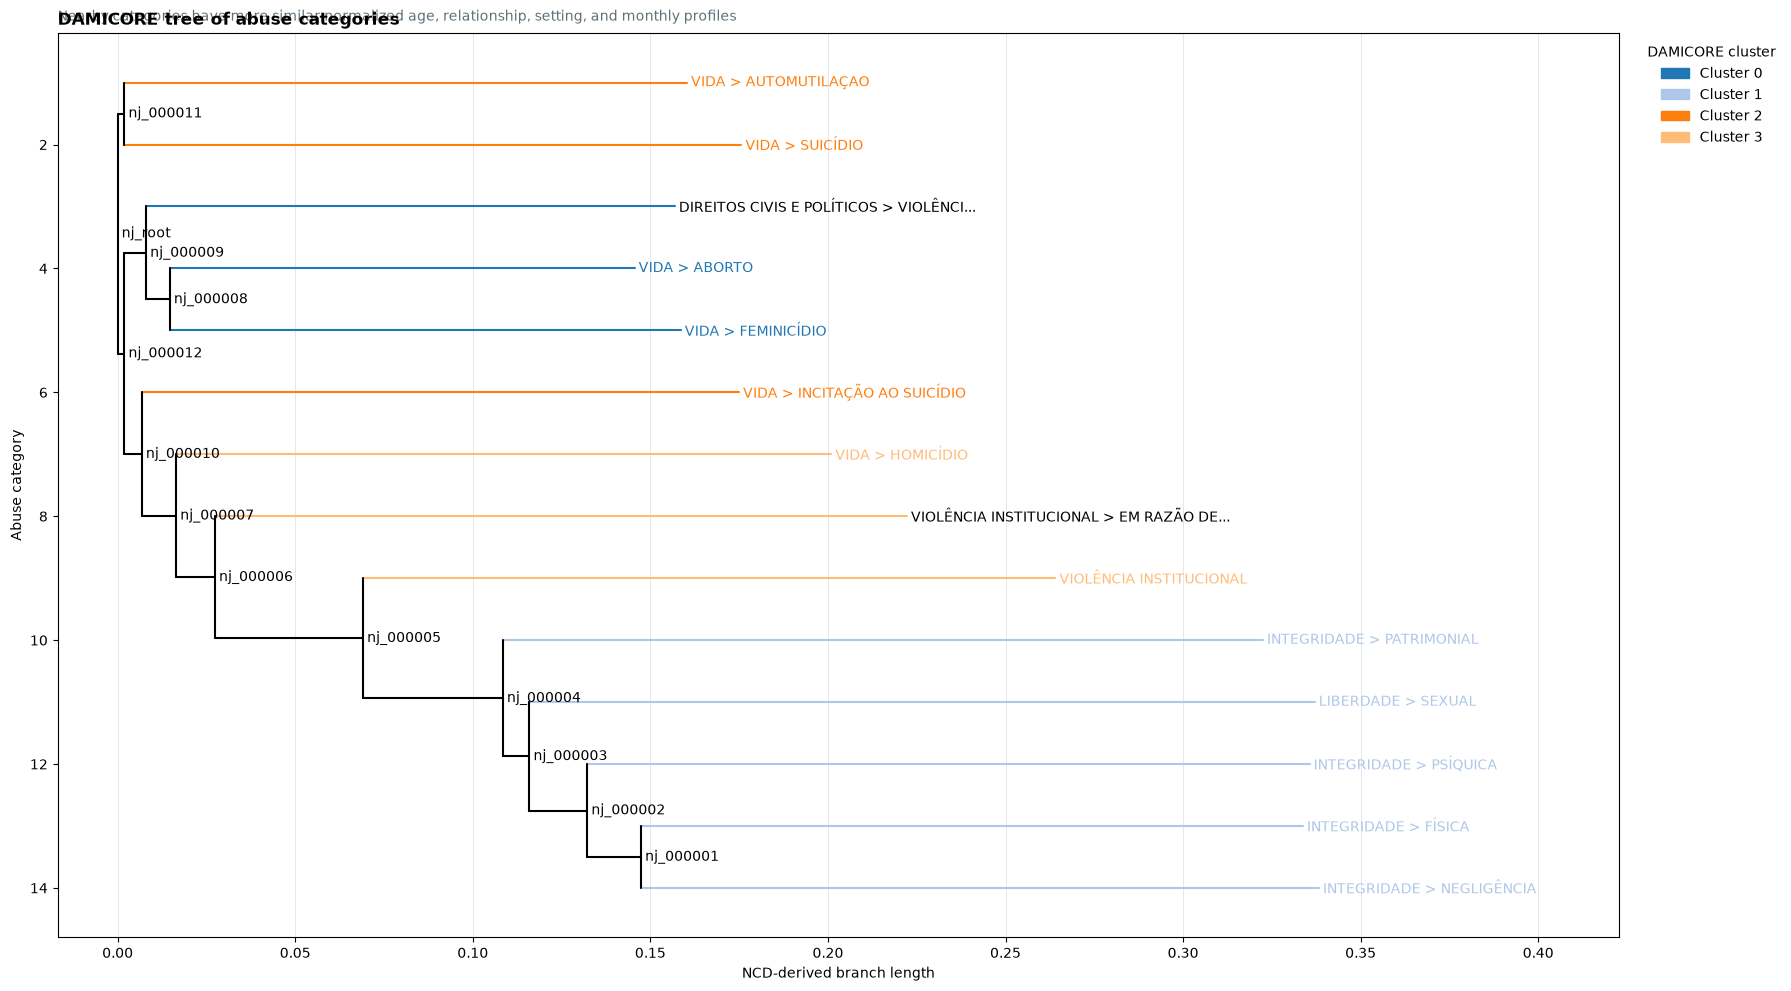

In [14]:
tree = Phylo.read(StringIO(tree_newick), "newick")
by_object_id = category_clusters.set_index("object_id")
by_label = category_clusters.set_index("label")
label_colors = {}

for terminal in tree.get_terminals():
    if terminal.name in by_object_id.index:
        category_row = by_object_id.loc[terminal.name]
    elif terminal.name in by_label.index:
        category_row = by_label.loc[terminal.name]
    else:
        raise KeyError(f"Unknown DAMICORE tree terminal: {terminal.name}")
    cluster = int(category_row["cluster"])
    terminal.name = category_row["category"]
    terminal.color = cluster_hex_colors[cluster]
    label_colors[terminal.name] = cluster_hex_colors[cluster]

figure_height = max(10, len(category_clusters) * 0.34)
figure, axis = plt.subplots(figsize=(18, figure_height))
Phylo.draw(
    tree,
    axes=axis,
    do_show=False,
    show_confidence=False,
    label_colors=label_colors,
)
axis.set_title("DAMICORE tree of abuse categories", loc="left", weight="bold")
axis.text(
    0, 1.01,
    "Nearby categories have more similar normalized age, relationship, setting, and monthly profiles",
    transform=axis.transAxes, color="#607078", fontsize=10, va="bottom",
)
axis.set_xlabel("NCD-derived branch length")
axis.set_ylabel("Abuse category")
axis.legend(
    handles=[Patch(color=cluster_hex_colors[cluster], label=f"Cluster {cluster}") for cluster in clusters],
    title="DAMICORE cluster", loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False,
)
axis.grid(axis="x", color="#E2E7E9", linewidth=0.7)
figure.tight_layout()
figure.savefig(RESULTS_DIR / "category-tree.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()


## 6. Graph 1 — DAMICORE cluster to abuse category

Every edge comes directly from DAMICORE membership. Larger category nodes and thicker edges indicate more distinct reports.


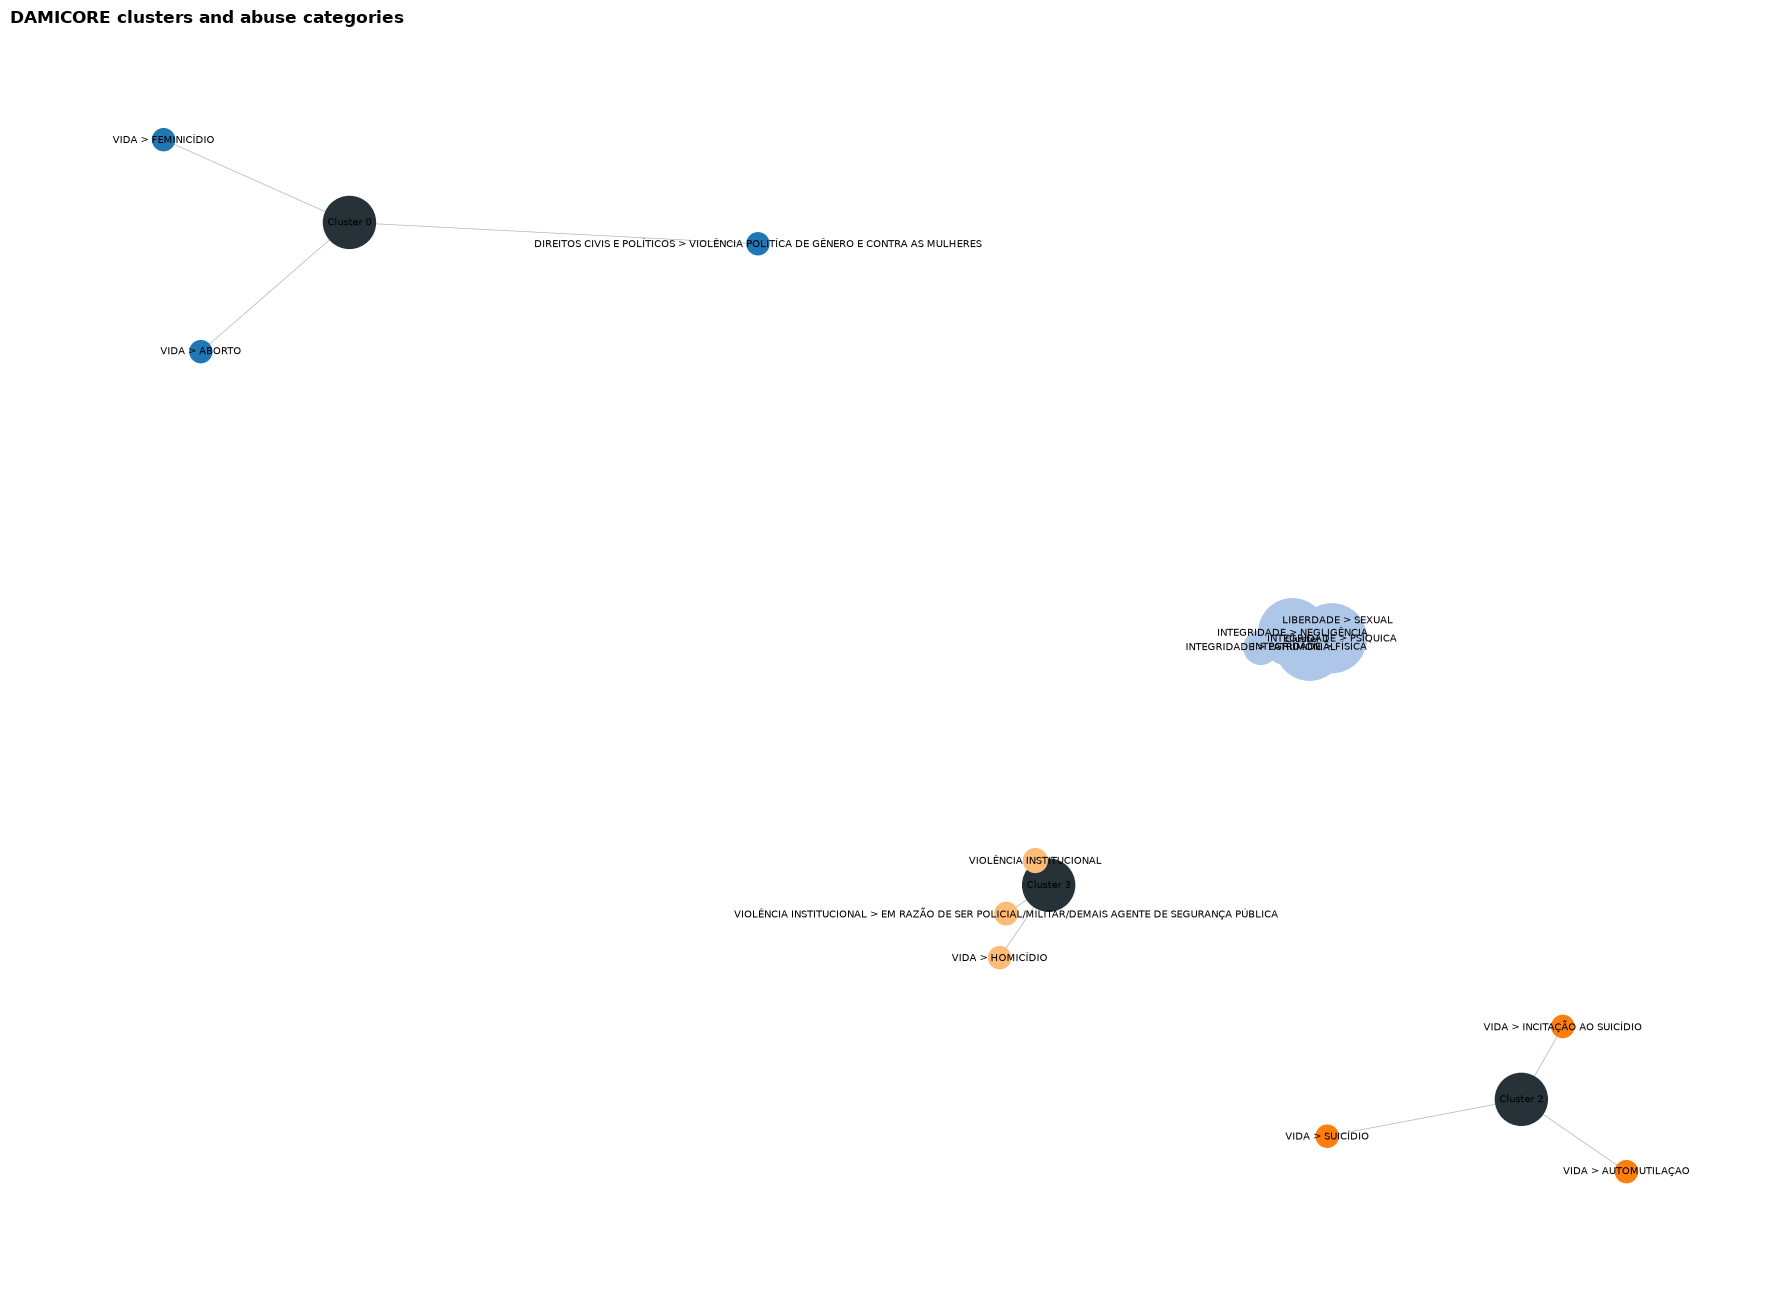

In [15]:
cluster_graph = nx.Graph(experiment="DAMICORE abuse categories 2026 H1")
for row in category_clusters.itertuples(index=False):
    cluster_node = f"cluster:{row.cluster}"
    category_node = f"category:{row.label}"
    cluster_graph.add_node(cluster_node, node_type="cluster", label=f"Cluster {row.cluster}")
    cluster_graph.add_node(
        category_node, node_type="category", label=row.category,
        cluster=int(row.cluster), report_count=int(row.report_count),
    )
    cluster_graph.add_edge(cluster_node, category_node, report_count=int(row.report_count))

for cluster in category_clusters["cluster"].unique():
    node = f"cluster:{cluster}"
    cluster_graph.nodes[node]["report_count"] = int(
        category_clusters.loc[category_clusters["cluster"] == cluster, "report_count"].sum()
    )

nx.write_graphml(cluster_graph, RESULTS_DIR / "category-clusters.graphml")

max_support = category_clusters["report_count"].max()
positions = nx.spring_layout(cluster_graph, seed=42, weight="report_count", k=1.4)
node_sizes = [
    1400 if data["node_type"] == "cluster"
    else 250 + 2200 * data["report_count"] / max_support
    for _, data in cluster_graph.nodes(data=True)
]
node_colors = [
    "#263238" if data["node_type"] == "cluster" else cluster_colors[data["cluster"]]
    for _, data in cluster_graph.nodes(data=True)
]
edge_widths = [0.5 + 5 * data["report_count"] / max_support for _, _, data in cluster_graph.edges(data=True)]
labels = {node: data["label"] for node, data in cluster_graph.nodes(data=True)}

figure, axis = plt.subplots(figsize=(18, 13))
nx.draw_networkx(
    cluster_graph, positions, labels=labels, ax=axis,
    node_size=node_sizes, node_color=node_colors,
    width=edge_widths, edge_color="#AAB5B8", font_size=7,
)
axis.set_title("DAMICORE clusters and abuse categories", loc="left", weight="bold")
axis.axis("off")
figure.tight_layout()
figure.savefig(RESULTS_DIR / "category-clusters.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()


## 7. Graph 2 — two nearest categories by NCD

Each category points to its two smallest non-self distances. Edge thickness represents `1 / (1 + NCD)`, so thicker edges mean greater similarity.


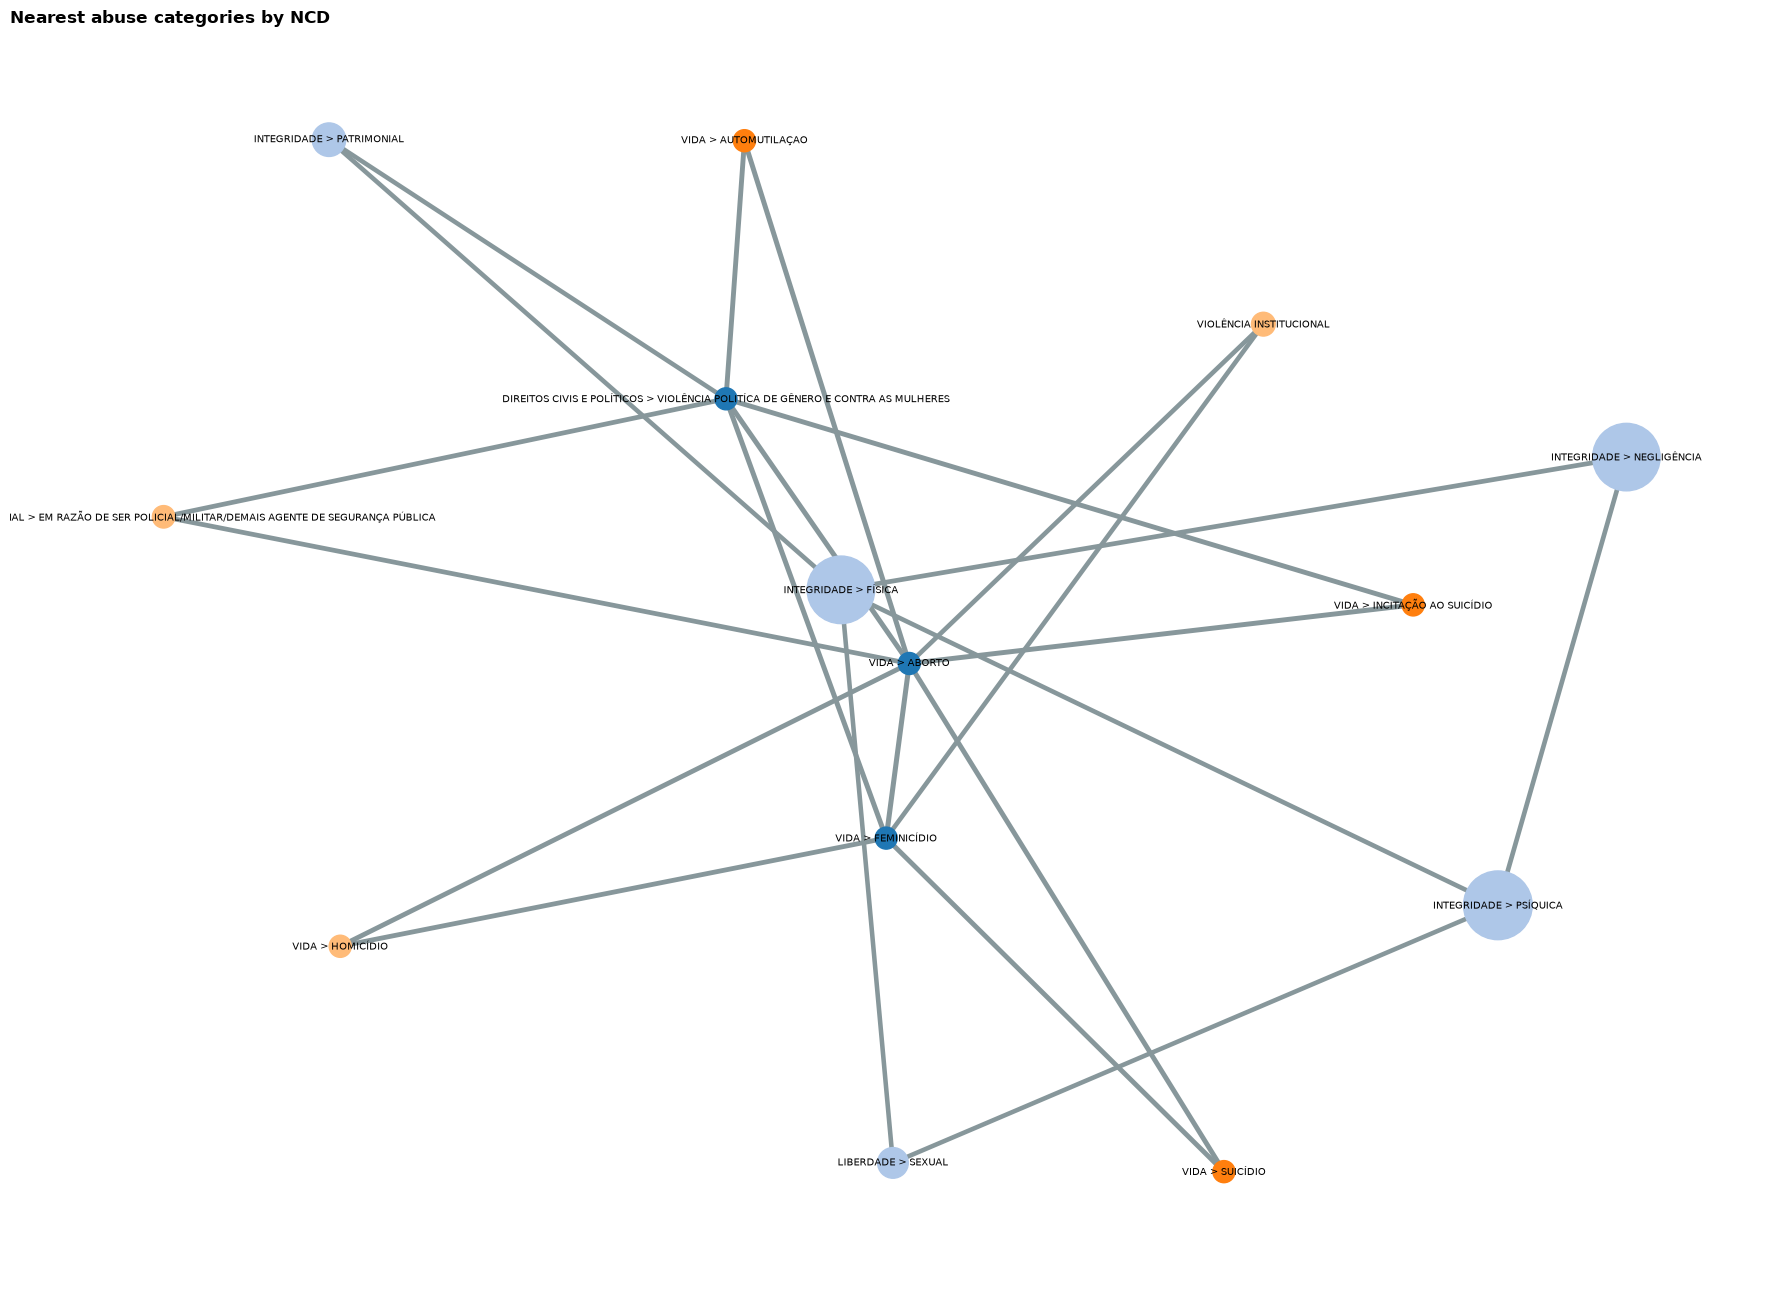

In [16]:
similarity_graph = nx.Graph(experiment="DAMICORE category similarity 2026 H1")
cluster_by_label = category_clusters.set_index("label")

for label, row in cluster_by_label.iterrows():
    similarity_graph.add_node(
        label, node_type="category", label=row["category"],
        cluster=int(row["cluster"]), report_count=int(row["report_count"]),
    )

for label in distance_matrix.index:
    for neighbor, ncd in distance_matrix.loc[label].drop(label).nsmallest(2).items():
        ncd = float(ncd)
        if not similarity_graph.has_edge(label, neighbor) or ncd < similarity_graph[label][neighbor]["ncd_distance"]:
            similarity_graph.add_edge(
                label, neighbor, ncd_distance=ncd, similarity=1.0 / (1.0 + ncd)
            )

nx.write_graphml(similarity_graph, RESULTS_DIR / "category-similarity.graphml")

positions = nx.spring_layout(similarity_graph, seed=42, weight="similarity", k=1.2)
node_sizes = [
    250 + 2200 * data["report_count"] / max_support
    for _, data in similarity_graph.nodes(data=True)
]
node_colors = [cluster_colors[data["cluster"]] for _, data in similarity_graph.nodes(data=True)]
edge_widths = [0.5 + 4 * data["similarity"] for _, _, data in similarity_graph.edges(data=True)]
labels = {node: data["label"] for node, data in similarity_graph.nodes(data=True)}

figure, axis = plt.subplots(figsize=(18, 13))
nx.draw_networkx(
    similarity_graph, positions, labels=labels, ax=axis,
    node_size=node_sizes, node_color=node_colors,
    width=edge_widths, edge_color="#87979B", font_size=7,
)
axis.set_title("Nearest abuse categories by NCD", loc="left", weight="bold")
axis.axis("off")
figure.tight_layout()
figure.savefig(RESULTS_DIR / "category-similarity.png", dpi=180, bbox_inches="tight", facecolor="white")
plt.show()


## Interpretation limit

DAMICORE groups eligible source categories whose normalized age, relationship, setting, and monthly prevalence profiles compress similarly. Interpret the tree and graphs only when the bias diagnostic is acceptable. Even then, clusters are exploratory contextual profiles—not confirmed legal or social typologies of abuse—and excluded sparse categories require a separate descriptive analysis.
